**We will begin with a Logistic Regression Model to predict the attrition of an employee**

In [11]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = df = pd.read_csv(
    "../data/processed/Employee-Attrition_Regression_Ready.csv"
)
df.head()

,Unnamed: 0,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,0,0.446350,1,0.742527,-1.010909,2,2,1.383138,3,2,...,0,0,0,0,0,1,0,0,0,1
1,1,1.322365,0,-1.297775,-0.147150,1,3,-0.240677,2,2,...,0,0,0,0,1,0,0,0,1,0
2,2,0.008343,1,1.414363,-0.887515,2,4,1.284725,2,1,...,1,0,0,0,0,0,0,0,0,1
3,3,-0.429664,0,1.461466,-0.764121,4,4,-0.486709,3,1,...,0,0,0,0,1,0,0,0,1,0
4,4,-1.086676,0,-0.524295,-0.887515,1,1,-1.274014,3,1,...,1,0,0,0,0,0,0,0,1,0


The data is already processesd and ready to train a model in a previous notebook. All columns were converted into numeric values and all categories are one-hot encoded. The data frame needs to be split into an X and Y.
In the Attrition column, a 1 indicates an employee left, 0 means an employee stayed.

In [12]:
X = df.drop(columns='Attrition')
Y = df['Attrition']

print(X.shape)
print(Y.shape)

print(Y.value_counts())

(1470, 51)
(1470,)
Attrition
0    1233
1     237
Name: count, dtype: int64


Here we split the the data into a testing and training data. 'random_state' is like a seed that makes sure that everyone running the code gets the same result. But why 42? Because it's the answer to Life, the Universe, and Everything. 'satisfy' is needed, because we have far more non-attrition employees. This ensures the proportions are kept.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.2, random_state = 42, stratify=Y
)

print(X_train.shape)
print(Y_train.shape)

(1176, 51)
(1176,)


Time to actually train the model.

In [ ]:
logistic_model = LogisticRegression(max_iter = 1000, random_state = 42)

logistic_model.fit(X_train, Y_train)

Y_pred = logistic_model.predict(X_test)

c:\Users\dhant\Desktop\NPower\Activity\group_Proj\ibm-analytics-attrition-eda\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Now we test the model's accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

accuracy =  accuracy_score(Y_test, Y_pred)

print(f"Accuracy: {round((accuracy * 100), 2)}%")

Accuracy: 85.71%


Interesting score, but we need further evaluation to really understand what's going on. Let's use a classification report.

In [27]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.60      0.32      0.42        47

    accuracy                           0.86       294
   macro avg       0.74      0.64      0.67       294
weighted avg       0.84      0.86      0.84       294



See the row '1', employees who left, 'precision' and 'recall' give important information. 
* 1. Percision states: of employees predicted to leave, how many actually left? Only 60%.
* 2. Recall states: of employees who left, how many did the model successfully identify? Only 32%
See the row '0', employees who stayed.
* 1. Of the employees predicted to stay, how many actually stayed? 88%
* 2. Of the employees who stayed, how many did the model correctly predict? 96%

What does this tell us?
* The model excells at predicting if an employee stays but struggles to identify employees who actually left.

A confusion matrix will help illustrate this.

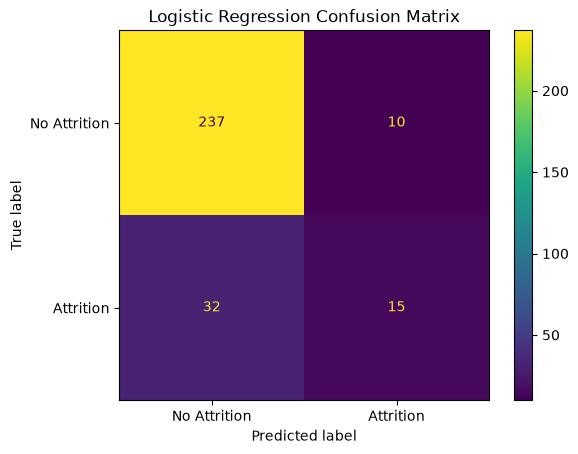

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, Y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Attrition', 'Attrition']
)

disp.plot()
plt.title('Logistic Regression Confusion Matrix')
plt.show()